In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('../Data/Risk_data_FE.csv')

In [2]:
df.head()

,Unnamed: 0,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,...,credit_age_bucket,age_bucket,income_bucket,has_delinquency,utilization_bucket,loan_grade_numeric,interest_rate_bucket,loan_amount_bucket,emp_stability,risk_interaction
0,1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,...,short,18-25,<30k,1,medium,2,8-12%,<2k,2.500000,0.159031
1,2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,...,medium,18-25,<30k,0,high,3,12-16%,5-10k,0.333333,0.645982
2,3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,...,short,18-25,60-100k,0,medium,3,12-16%,20k+,2.000000,0.244136
3,4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,...,medium,18-25,30-60k,0,low,3,12-16%,20k+,2.000000,0.212279
4,5,CUST_00006,21,9900,OWN,2.0,VENTURE,A,2500,7.14,...,short,18-25,<30k,0,high,1,<8%,2-5k,1.000000,0.393613


In [3]:
df.columns

Index(['Unnamed: 0', 'client_ID', 'person_age', 'person_income',
       'person_home_ownership', 'person_emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'gender', 'marital_status',
       'education_level', 'country', 'state', 'city', 'city_latitude',
       'city_longitude', 'employment_type', 'loan_term_months',
       'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio',
       'open_accounts', 'credit_utilization_ratio', 'past_delinquencies',
       'emp_length_num', 'installment', 'installment_income_ratio',
       'total_debt_after_loan', 'debt_burden', 'credit_age_bucket',
       'age_bucket', 'income_bucket', 'has_delinquency', 'utilization_bucket',
       'loan_grade_numeric', 'interest_rate_bucket', 'loan_amount_bucket',
       'emp_stability', 'risk_interaction'],
      dtype='str')

In [4]:
df = df.drop(columns = ['Unnamed: 0'])

In [5]:
df.shape

(31679, 44)

Tỷ lệ default theo từng nhóm tuổi (age_bucket)

In [6]:
# Tính trung bình tỷ lệ default
default_stats = (
    df.groupby("age_bucket")["loan_status"]
      .agg(["count", "sum", "mean"])
      .reset_index()
      .rename(columns={
          "count": "total_loans",
          "sum": "num_default",
          "mean": "default_rate"
      })
)

default_stats

,age_bucket,total_loans,num_default,default_rate
0,18-25,14891,3393,0.227856
1,26-35,13415,2739,0.204174
2,36-45,2736,555,0.202851
3,46-55,505,106,0.209901
4,56-65,103,27,0.262136
5,66+,29,5,0.172414


In [7]:
default_stats = (
    df.groupby("age_bucket")["loan_status"]
      .agg(["count", "sum", "mean"])
      .reset_index()
      .rename(columns={
          "count": "total_loans",
          "sum": "num_default",
          "mean": "default_rate"
      })
)

default_stats


,age_bucket,total_loans,num_default,default_rate
0,18-25,14891,3393,0.227856
1,26-35,13415,2739,0.204174
2,36-45,2736,555,0.202851
3,46-55,505,106,0.209901
4,56-65,103,27,0.262136
5,66+,29,5,0.172414


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\226198306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_stats,


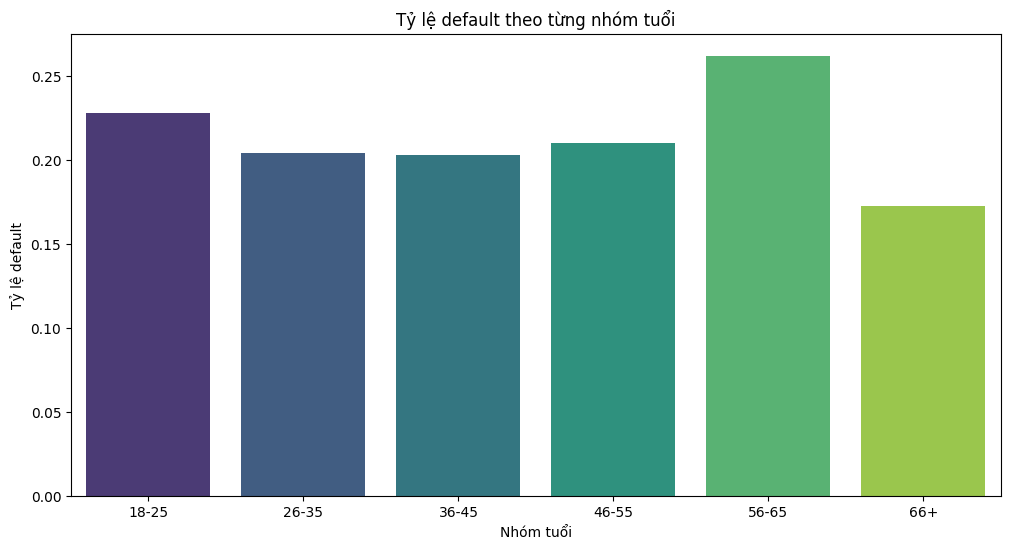

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(data=default_stats,
            x = 'age_bucket',
            y = 'default_rate',
            palette = 'viridis')
plt.title('Tỷ lệ default theo từng nhóm tuổi')
plt.ylabel('Tỷ lệ default')
plt.xlabel('Nhóm tuổi')
plt.show()

Tỷ lệ default theo từng loan_intent

In [10]:
default_stats_intent = (
    df.groupby('loan_intent')['loan_status']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
    .rename(columns = {
        'count':'total_loan',
        'sum':'num_default',
        'mean': 'default_rate'
    })
)
default_stats_intent

,loan_intent,total_loan,num_default,default_rate
0,DEBTCONSOLIDATION,5064,1437,0.283768
1,EDUCATION,6288,1066,0.169529
2,HOMEIMPROVEMENT,3510,897,0.255556
3,MEDICAL,5897,1565,0.265389
4,PERSONAL,5367,1046,0.194895
5,VENTURE,5553,814,0.146587


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\570289562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


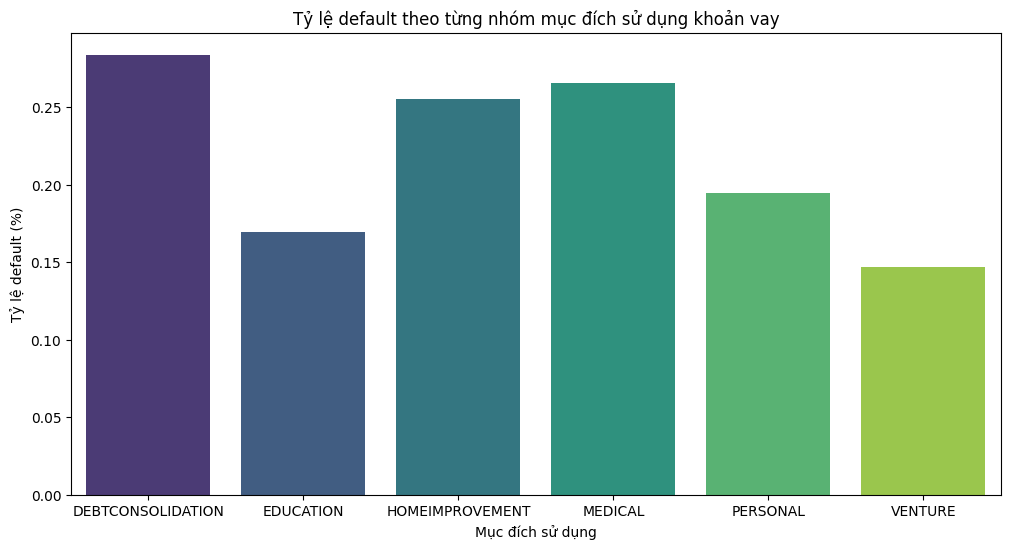

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(
    data = default_stats_intent,
    x = 'loan_intent',
    y = 'default_rate',
    palette= 'viridis'
)
plt.title('Tỷ lệ default theo từng nhóm mục đích sử dụng khoản vay')
plt.xlabel('Mục đích sử dụng')
plt.ylabel('Tỷ lệ default (%)')
plt.show()

Tỷ lệ default theo từng country

In [12]:
default_stats_country = (
    df.groupby('country')['loan_status']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
    .rename(columns = {
        'sum': 'total_loan',
        'sum': 'num_default',
        'mean': 'default_rate'
    })
)
default_stats_country

,country,count,num_default,default_rate
0,Canada,10481,2265,0.216105
1,UK,10658,2287,0.214581
2,USA,10540,2273,0.215655


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2411098439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


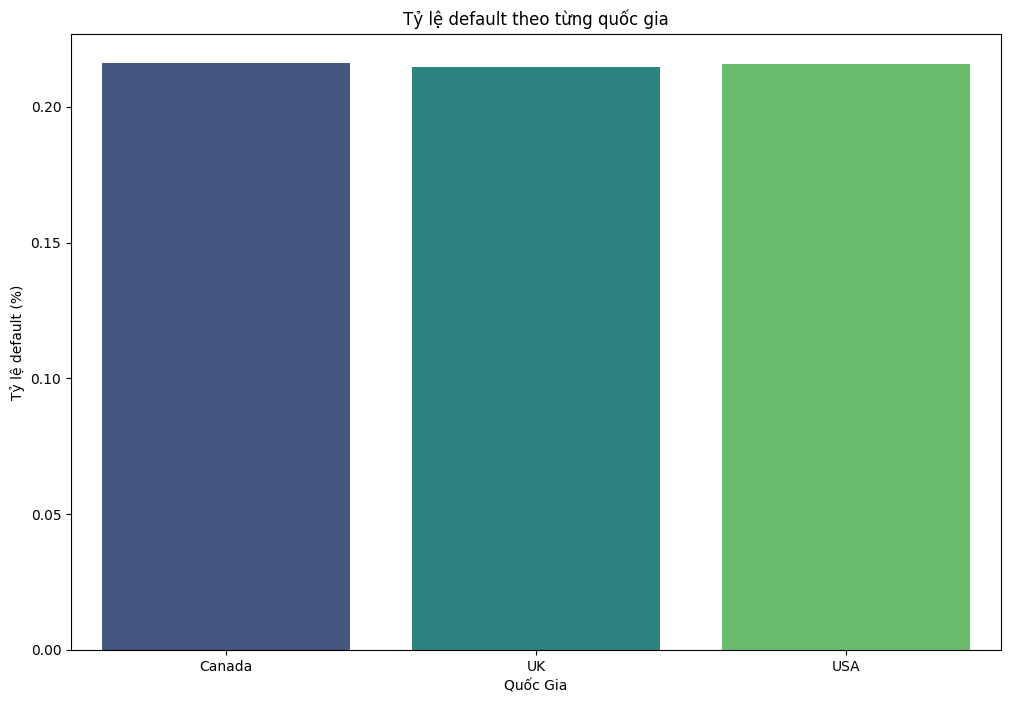

In [13]:
plt.figure(figsize=(12,8))
sns.barplot(
    data = default_stats_country,
    x = 'country',
    y = 'default_rate',
    palette= 'viridis'
)
plt.title('Tỷ lệ default theo từng quốc gia')
plt.xlabel('Quốc Gia')
plt.ylabel('Tỷ lệ default (%)')
plt.show()

In [14]:
# tong gia tri cac khoan vay
df['loan_amnt'].sum()

np.int64(306017950)

In [15]:
# Tỷ lệ default trung bình
overall_default_rate = df['loan_status'].mean()
overall_default_rate

np.float64(0.21544240664162378)

In [16]:
# lãi vay trung bình
overall_loan_int_rate = df['loan_int_rate'].mean()
overall_loan_int_rate

np.float64(11.041722434420278)

In [17]:
# tổng khối lượng các khoản vay
total_of_loan = df['loan_amnt'].sum()
total_of_loan

np.int64(306017950)

In [18]:
# Trung bình các khoản vay
avg_of_loan = df['loan_amnt'].mean()
avg_of_loan

np.float64(9659.962435682944)

In [19]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_num', 'installment',
       'installment_income_ratio', 'total_debt_after_loan', 'debt_burden',
       'credit_age_bucket', 'age_bucket', 'income_bucket', 'has_delinquency',
       'utilization_bucket', 'loan_grade_numeric', 'interest_rate_bucket',
       'loan_amount_bucket', 'emp_stability', 'risk_interaction'],
      dtype='str')

In [20]:
heatmap_value = (
    df.groupby(['interest_rate_bucket','loan_amount_bucket'])['loan_status']
    .mean()
    .reset_index()
    .rename(columns= {
        'loan_status': 'default_rate'
    })

)


heatmap_data = heatmap_value.pivot(
        index = 'interest_rate_bucket',
        columns =  'loan_amount_bucket',
        values = 'default_rate'
    )


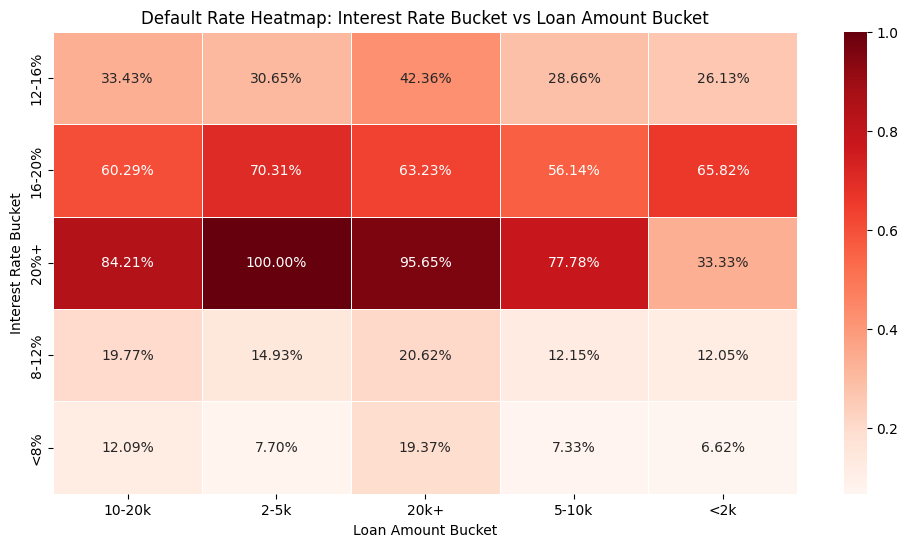

In [21]:
# heatmap lãi suất và khối lượng khoản vay
plt.figure(figsize = (12,6))
sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = '.2%',
    cmap ='Reds',
    linewidths=0.5

)
plt.title('Default Rate Heatmap: Interest Rate Bucket vs Loan Amount Bucket')
plt.xlabel('Loan Amount Bucket')
plt.ylabel('Interest Rate Bucket')
plt.show()

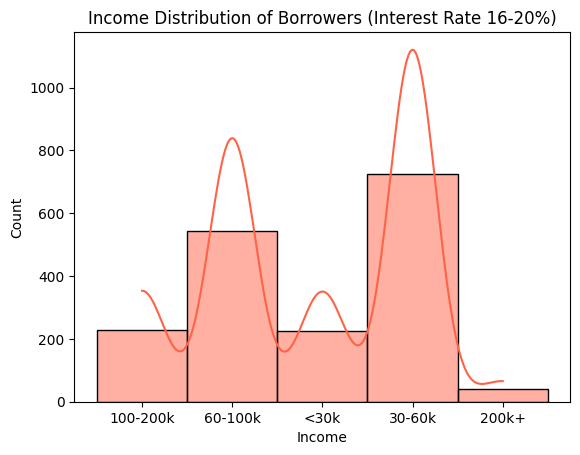

In [22]:
sns.histplot(
    data=df[df["interest_rate_bucket"] == "16-20%"],
    x="income_bucket",
    bins=30,
    kde=True,
    color="tomato"
)
plt.title("Income Distribution of Borrowers (Interest Rate 16-20%)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()


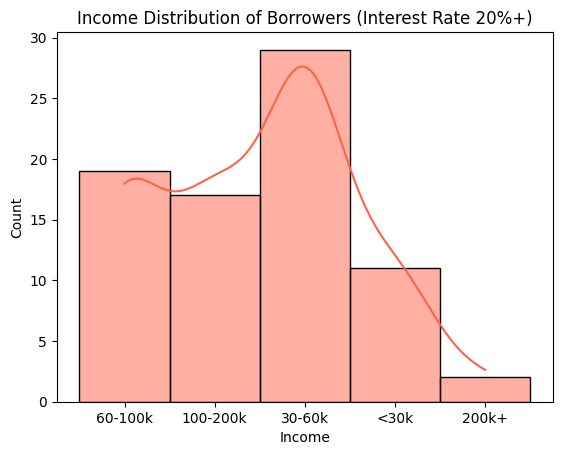

In [23]:
sns.histplot(
    data=df[df["interest_rate_bucket"] == "20%+"],
    x="income_bucket",
    bins=30,
    kde=True,
    color="tomato"
)
plt.title("Income Distribution of Borrowers (Interest Rate 20%+)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2354426944.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


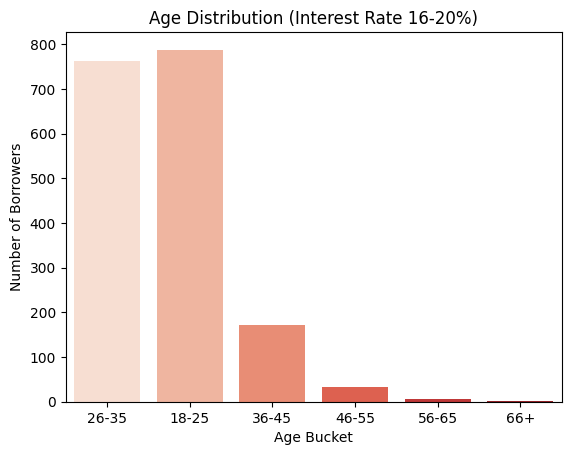

In [24]:
sns.countplot(
    data=df[df["interest_rate_bucket"] == "16-20%"],
    x="age_bucket",
    palette="Reds"
)
plt.title("Age Distribution (Interest Rate 16-20%)")
plt.xlabel("Age Bucket")
plt.ylabel("Number of Borrowers")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2864390884.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


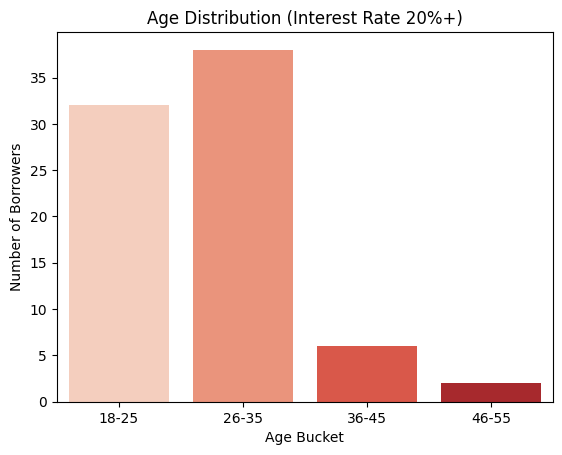

In [25]:
sns.countplot(
    data=df[df["interest_rate_bucket"] == "20%+"],
    x="age_bucket",
    palette="Reds"
)
plt.title("Age Distribution (Interest Rate 20%+)")
plt.xlabel("Age Bucket")
plt.ylabel("Number of Borrowers")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\3126956839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")


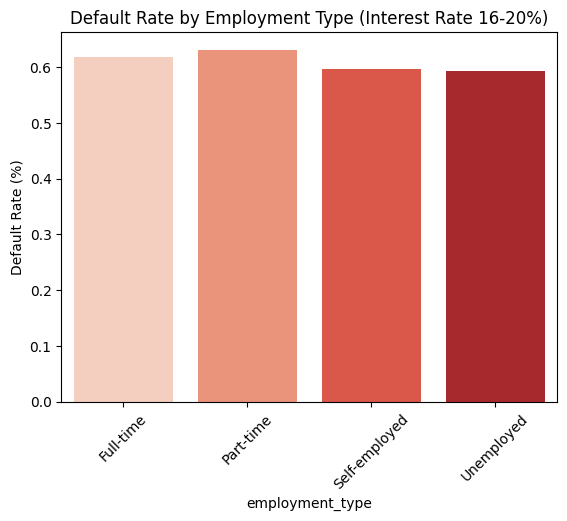

In [26]:
default_by_emp = (
    df[df["interest_rate_bucket"] == "16-20%"]
    .groupby("employment_type")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")
plt.title("Default Rate by Employment Type (Interest Rate 16-20%)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\3346307082.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")


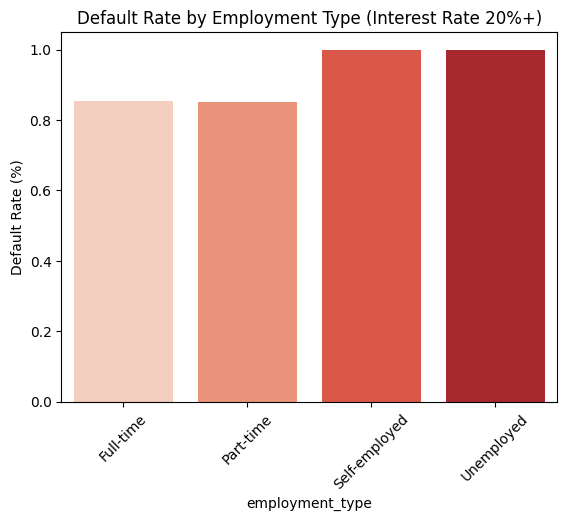

In [27]:
default_by_emp = (
    df[df["interest_rate_bucket"] == "20%+"]
    .groupby("employment_type")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")
plt.title("Default Rate by Employment Type (Interest Rate 20%+)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2148939259.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")


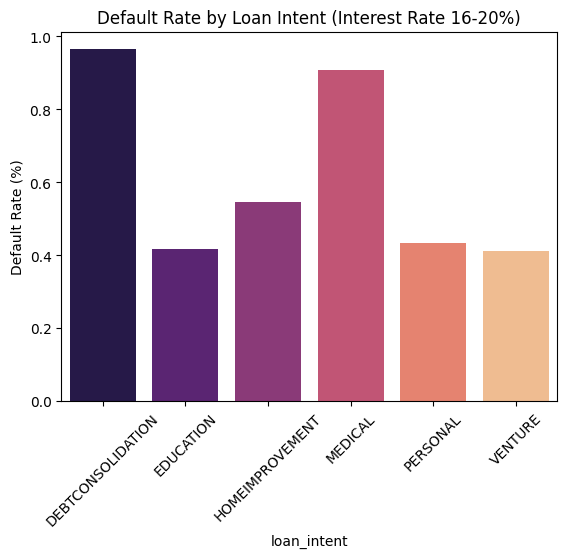

In [28]:
default_by_intent = (
    df[df["interest_rate_bucket"] == "16-20%"]
    .groupby("loan_intent")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")
plt.title("Default Rate by Loan Intent (Interest Rate 16-20%)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\4264237524.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")


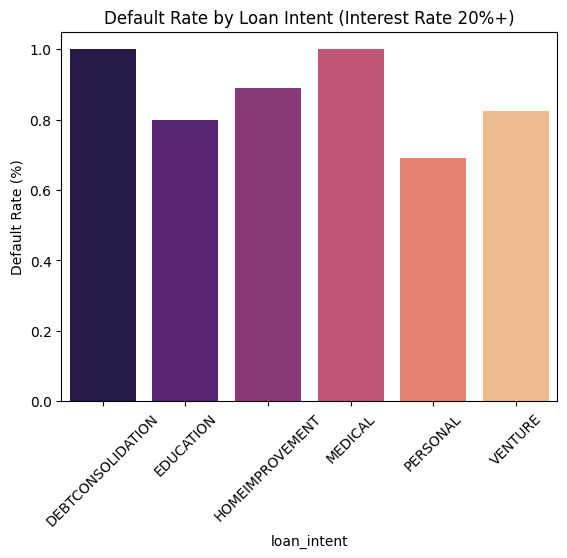

In [29]:
default_by_intent = (
    df[df["interest_rate_bucket"] == "20%+"]
    .groupby("loan_intent")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")
plt.title("Default Rate by Loan Intent (Interest Rate 20%+)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


Đi sâu phân tích theo từng nhóm lãi suất và từng nhóm khoản vay xem điều gì đang thực sự diễn ra ở đây, ai là những người vay những gói rủi ro cao như vậy


In [30]:
# Lọc theo nhóm vay từ 2-5k với mức lãi suất cao
subset = df[
    (df["loan_amount_bucket"] == "2-5k") &
    (df["interest_rate_bucket"].isin(["16-20%", "20%+"]))
]


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\3174794403.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=subset, x="age_bucket", palette="Reds")


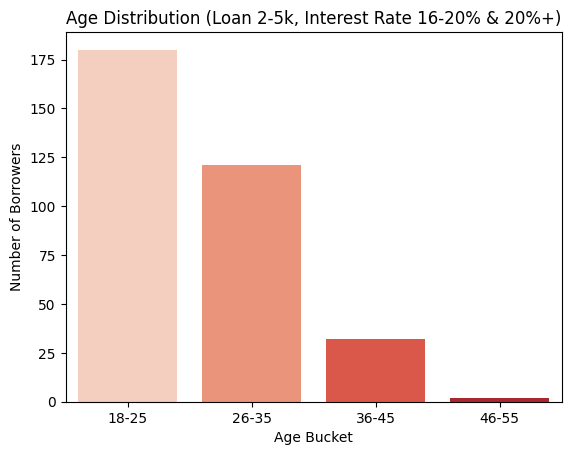

In [31]:
sns.countplot(data=subset, x="age_bucket", palette="Reds")
plt.title("Age Distribution (Loan 2-5k, Interest Rate 16-20% & 20%+)")
plt.xlabel("Age Bucket")
plt.ylabel("Number of Borrowers")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\1417949704.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=subset, x="income_bucket", palette="magma")


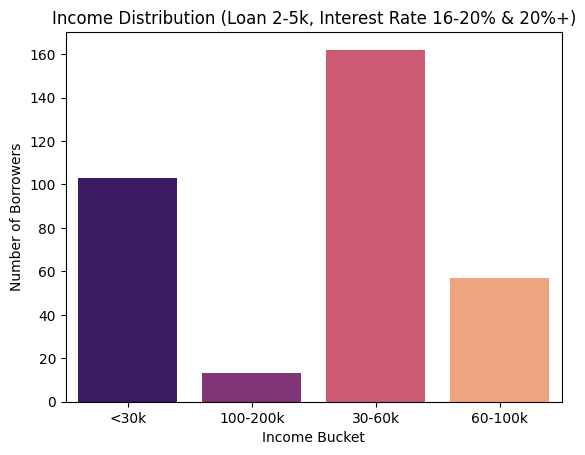

In [32]:
sns.countplot(data=subset, x="income_bucket", palette="magma")
plt.title("Income Distribution (Loan 2-5k, Interest Rate 16-20% & 20%+)")
plt.xlabel("Income Bucket")
plt.ylabel("Number of Borrowers")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2981158874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")


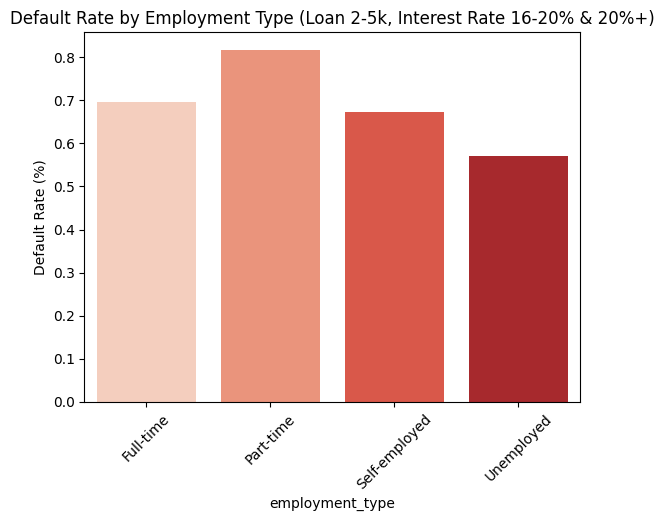

In [33]:
default_by_emp = (
    subset.groupby("employment_type")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_emp, x="employment_type", y="default_rate", palette="Reds")
plt.title("Default Rate by Employment Type (Loan 2-5k, Interest Rate 16-20% & 20%+)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\3366902554.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")


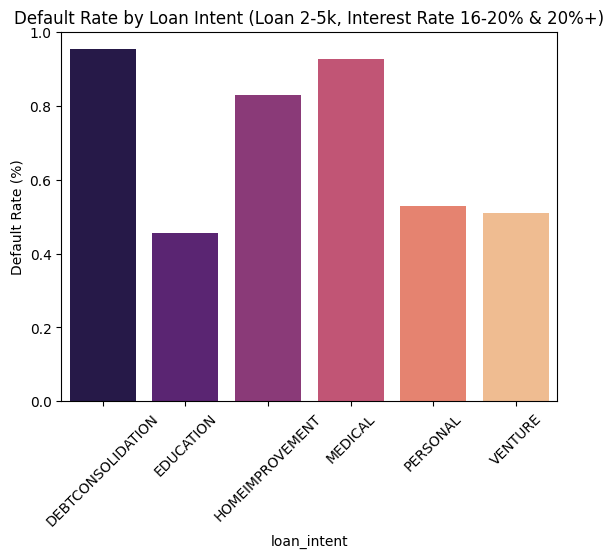

In [34]:
default_by_intent = (
    subset.groupby("loan_intent")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)

sns.barplot(data=default_by_intent, x="loan_intent", y="default_rate", palette="magma")
plt.title("Default Rate by Loan Intent (Loan 2-5k, Interest Rate 16-20% & 20%+)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate (%)")
plt.show()


heatmap với loại rủi ro cao


In [35]:
#Lọc dữ liệu để chỉ lấy 2 nhóm lãi suất có rủi ro cao
high_risk_df = df[df["interest_rate_bucket"].isin(["16-20%", "20%+"])]


In [36]:
#Tính default rate theo loan_amount_bucket × interest_rate_bucket
heatmap_group = (
    high_risk_df.groupby(["interest_rate_bucket", "loan_amount_bucket"])["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)


In [37]:
# Pivot để tạo heatmap matrix
heatmap_data = heatmap_group.pivot(
    index="interest_rate_bucket",
    columns="loan_amount_bucket",
    values="default_rate"
)


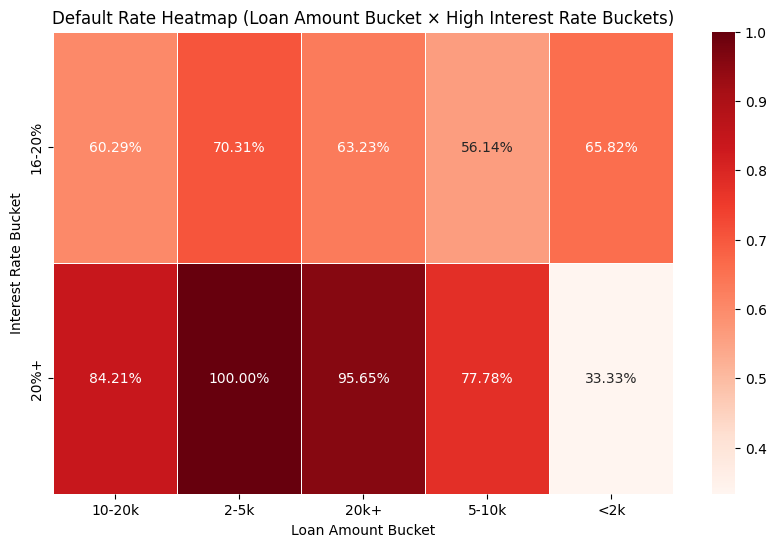

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2%",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Default Rate Heatmap (Loan Amount Bucket × High Interest Rate Buckets)")
plt.xlabel("Loan Amount Bucket")
plt.ylabel("Interest Rate Bucket")
plt.show()


In [39]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_num', 'installment',
       'installment_income_ratio', 'total_debt_after_loan', 'debt_burden',
       'credit_age_bucket', 'age_bucket', 'income_bucket', 'has_delinquency',
       'utilization_bucket', 'loan_grade_numeric', 'interest_rate_bucket',
       'loan_amount_bucket', 'emp_stability', 'risk_interaction'],
      dtype='str')

In [40]:
# Tạo DTI bucket
df["DTI_bucket"] = pd.cut(
    df["debt_to_income_ratio"] * 100,  # nhân 100 để chuyển sang %
    bins=[0, 10, 20, 30, 40, 50, 100],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", "40–50%", "50%+"],
    include_lowest=True
)


In [41]:
dti_default = (
    df.groupby("DTI_bucket")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\1385297296.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dti_default, x="DTI_bucket", y="default_rate", palette="Reds")


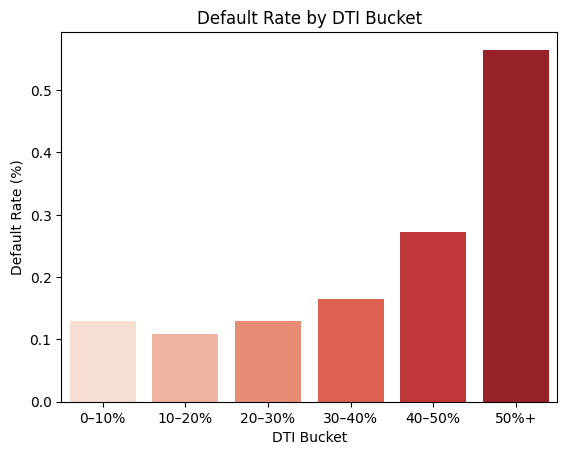

In [42]:
sns.barplot(data=dti_default, x="DTI_bucket", y="default_rate", palette="Reds")
plt.title("Default Rate by DTI Bucket")
plt.xlabel("DTI Bucket")
plt.ylabel("Default Rate (%)")
plt.show()


In [43]:
income_default = (
    df.groupby("income_bucket")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\3413952400.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=income_default, x="income_bucket", y="default_rate", palette="Reds")


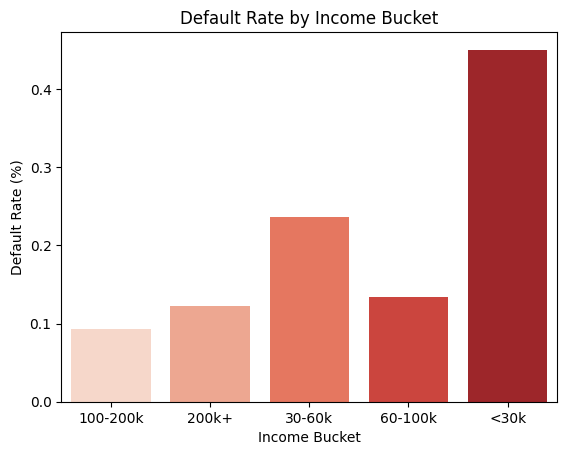

In [44]:
sns.barplot(data=income_default, x="income_bucket", y="default_rate", palette="Reds")
plt.title("Default Rate by Income Bucket")
plt.xlabel("Income Bucket")
plt.ylabel("Default Rate (%)")
plt.show()


In [45]:
df["risk_interaction_bucket"] = pd.qcut(
    df["risk_interaction"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)


In [46]:
risk_interaction_default = (
    df.groupby("risk_interaction_bucket")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2196588242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


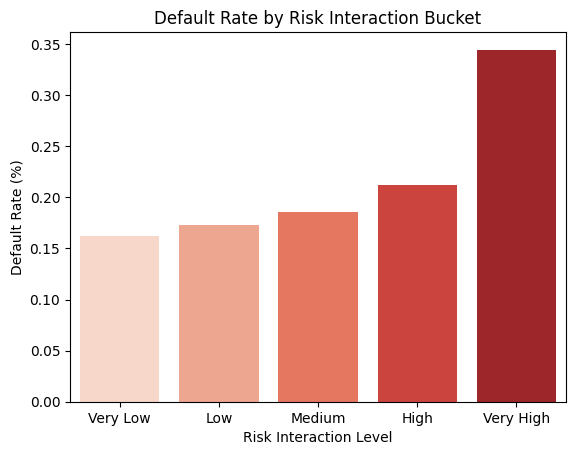

In [47]:
sns.barplot(
    data=risk_interaction_default,
    x="risk_interaction_bucket",
    y="default_rate",
    palette="Reds"
)
plt.title("Default Rate by Risk Interaction Bucket")
plt.xlabel("Risk Interaction Level")
plt.ylabel("Default Rate (%)")
plt.show()


In [48]:
#Kiểm tra độ chính xác của loan_grade
grade_default = (
    df.groupby("loan_grade")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)



C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\636340706.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grade_default, x="loan_grade", y="default_rate", palette="magma")


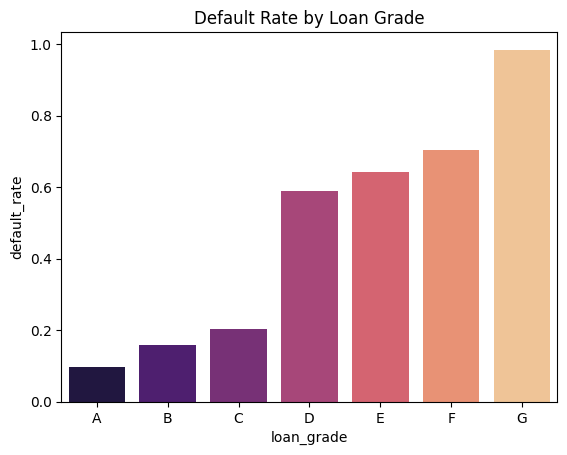

In [49]:
sns.barplot(data=grade_default, x="loan_grade", y="default_rate", palette="magma")
plt.title("Default Rate by Loan Grade")
plt.show()


In [50]:
df["installment_income_bucket"] = pd.cut(
    df["installment_income_ratio"] * 100,
    bins=[0, 5, 10, 15, 100],
    labels=["0–5%", "5–10%", "10–15%", "15%+"],
    include_lowest=True
)


In [51]:
install_default = (
    df.groupby("installment_income_bucket")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"loan_status": "default_rate"})
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_19128\2495476110.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


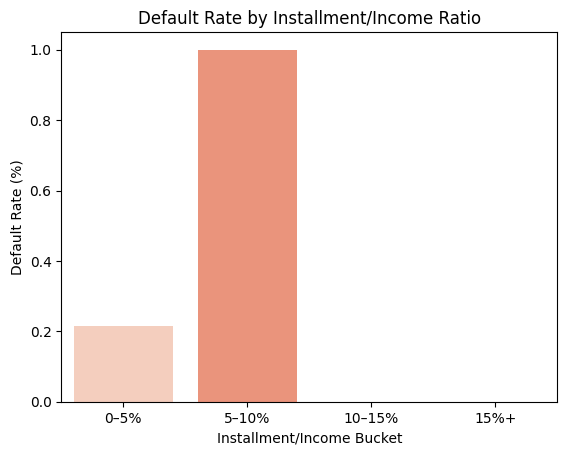

In [52]:
sns.barplot(
    data=install_default,
    x="installment_income_bucket",
    y="default_rate",
    palette="Reds"
)
plt.title("Default Rate by Installment/Income Ratio")
plt.xlabel("Installment/Income Bucket")
plt.ylabel("Default Rate (%)")
plt.show()


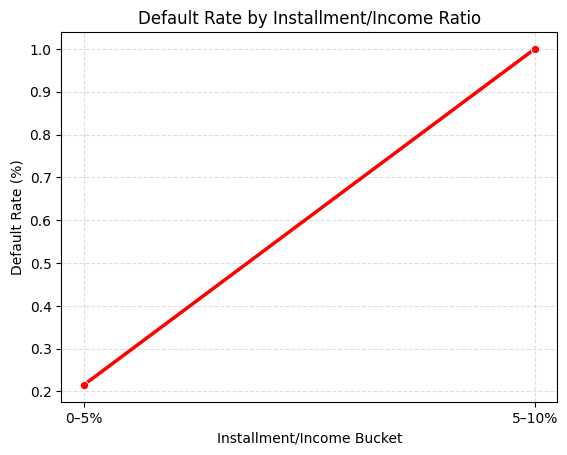

In [53]:
sns.lineplot(
    data=install_default,
    x="installment_income_bucket",
    y="default_rate",
    marker="o",
    linewidth=2.5,
    color="red"
)

plt.title("Default Rate by Installment/Income Ratio")
plt.xlabel("Installment/Income Bucket")
plt.ylabel("Default Rate (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [54]:
df['installment_income_ratio']

0        0.002894
1        0.015914
2        0.044529
3        0.017872
4        0.007015
           ...   
31674    0.003040
31675    0.002448
31676    0.019189
31677    0.002778
31678    0.002569
Name: installment_income_ratio, Length: 31679, dtype: float64

In [55]:
import pandas as pd
df = pd.read_csv('../Data/Rick_data_FE.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Rick_data_FE.csv'

In [ ]:
df.columns

Index(['Unnamed: 0', 'client_ID', 'person_age', 'person_income',
       'person_home_ownership', 'person_emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'gender', 'marital_status',
       'education_level', 'country', 'state', 'city', 'city_latitude',
       'city_longitude', 'employment_type', 'loan_term_months',
       'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio',
       'open_accounts', 'credit_utilization_ratio', 'past_delinquencies',
       'emp_length_num', 'installment', 'installment_income_ratio',
       'total_debt_after_loan', 'debt_burden', 'credit_age_bucket',
       'age_bucket', 'income_bucket', 'has_delinquency', 'utilization_bucket',
       'loan_grade_numeric', 'interest_rate_bucket', 'loan_amount_bucket',
       'emp_stability', 'risk_interaction'],
      dtype='str')

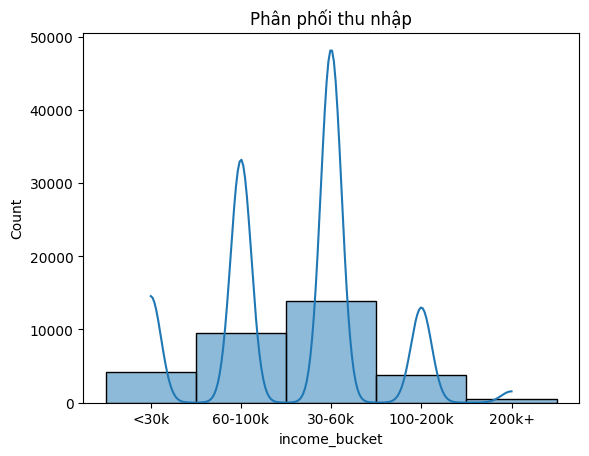

In [ ]:
sns.histplot(df['income_bucket'], kde=True)
plt.title("Phân phối thu nhập")
plt.show()
